In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from scipy.stats import chi2
import os # For path creation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# --- Feature Extraction Functions ---

def calculate_bfd(byte_sequence):
    """Calculates Byte Frequency Distribution (256 values)."""
    bfd = np.zeros(256, dtype=np.float32)
    if len(byte_sequence) == 0:
        return bfd
    for byte_val in byte_sequence:
        bfd[int(byte_val)] += 1
    return bfd / len(byte_sequence) # Normalize

def calculate_dft_features(byte_sequence, num_coeffs=5):
    """Calculates DFT features: 'num_coeffs' highest magnitude coefficients and their indices (2 * num_coeffs values)."""
    sequence_len = len(byte_sequence)
    if sequence_len < 2:
        return np.zeros(2 * num_coeffs, dtype=np.float32)
    fft_coeffs = np.fft.fft(byte_sequence)
    unique_magnitudes_len = sequence_len // 2 + 1
    magnitudes = np.abs(fft_coeffs[:unique_magnitudes_len])
    if len(magnitudes) == 0:
        return np.zeros(2 * num_coeffs, dtype=np.float32)
    actual_num_coeffs_to_select = min(num_coeffs, len(magnitudes))
    if actual_num_coeffs_to_select == 0:
        return np.zeros(2 * num_coeffs, dtype=np.float32)
    top_indices_sorted_by_magnitude = np.argsort(magnitudes)[-actual_num_coeffs_to_select:]
    top_magnitudes_selected = magnitudes[top_indices_sorted_by_magnitude]
    dft_feats = np.zeros(2 * num_coeffs, dtype=np.float32)
    sum_all_unique_magnitudes = np.sum(magnitudes)
    top_magnitudes_normalized = top_magnitudes_selected / sum_all_unique_magnitudes if sum_all_unique_magnitudes > 0 else top_magnitudes_selected
    for i in range(actual_num_coeffs_to_select):
        dft_feats[i] = top_magnitudes_normalized[i]
        if (sequence_len // 2) > 0 :
            dft_feats[i + num_coeffs] = float(top_indices_sorted_by_magnitude[i]) / (sequence_len // 2)
        else:
            dft_feats[i + num_coeffs] = 0.0
    return dft_feats

def calculate_lempel_ziv_complexity(byte_sequence_np):
    """Calculates Lempel-Ziv complexity (LZ76 variant simplified)."""
    if byte_sequence_np.size == 0: return 0.0
    data = [str(b) for b in byte_sequence_np] # Convert bytes to strings for dictionary keys
    n = len(data)
    if n == 0: return 0.0
    dictionary = {}
    w = ""
    complexity = 0
    for i in range(n):
        c = data[i]
        wc = w + c
        if wc in dictionary:
            w = wc
        else:
            dictionary[wc] = len(dictionary) # Store the new phrase
            w = c # Start new phrase with current char
            complexity += 1
            # Crucial for LZ76: if the single character 'c' itself starts a new phrase
            # and is not yet in the dictionary (only for the very first occurrence of 'c' as a new phrase start)
            if w not in dictionary:
                 dictionary[w] = len(dictionary)
    return float(complexity)

def get_chi_squared_stats(byte_sequence):
    """
    Calculates Pearson's chi-squared statistic and its p-value.
    Returns: (chi_squared_statistic, p_value)
    """
    n = len(byte_sequence)
    if n == 0:
        return 0.0, 1.0

    bfd_counts = np.zeros(256, dtype=np.int_)
    for byte_val in byte_sequence:
        bfd_counts[int(byte_val)] += 1
    expected_count = n / 256.0
    if expected_count == 0:
        return 0.0, 1.0
    chi_squared_stat = np.sum(((bfd_counts - expected_count)**2) / expected_count)
    df = 255
    p_value = 1.0 - chi2.cdf(chi_squared_stat, df)
    return float(chi_squared_stat), float(p_value)

def calculate_monte_carlo_pi_approx(byte_sequence):
    """Calculates Monte Carlo pi approximation feature (1 value)."""
    n = len(byte_sequence)
    if n < 2: return 0.0
    num_pairs = n // 2
    if num_pairs == 0: return 0.0
    points_in_circle = 0
    for i in range(num_pairs):
        x = byte_sequence[2*i] / 255.0; y = byte_sequence[2*i + 1] / 255.0
        if (x - 0.5)**2 + (y - 0.5)**2 <= 0.5**2: points_in_circle += 1
    pi_approximation = 4.0 * (points_in_circle / num_pairs) if num_pairs > 0 else 0.0
    return float(pi_approximation)

def extract_all_features(byte_sequence):
    """Combines all feature extraction steps for one sequence to produce 270 features."""
    bfd_features = calculate_bfd(byte_sequence)
    dft_features_ = calculate_dft_features(byte_sequence)
    lempel_ziv_feature = calculate_lempel_ziv_complexity(byte_sequence)
    chi_sq_stat, chi_sq_p_value = get_chi_squared_stats(byte_sequence)
    monte_carlo_feature = calculate_monte_carlo_pi_approx(byte_sequence)
    return np.concatenate((
        bfd_features, dft_features_,
        np.array([lempel_ziv_feature], dtype=np.float32),
        np.array([chi_sq_stat], dtype=np.float32),
        np.array([chi_sq_p_value], dtype=np.float32),
        np.array([monte_carlo_feature], dtype=np.float32)))
class DNN_BFLCp(nn.Module):
    def __init__(self, input_features=270, num_classes=2):
        super(DNN_BFLCp, self).__init__()
        self.network = nn.Sequential(
            nn.Dropout(0.2), nn.Linear(input_features, 1024), nn.ReLU(),
            nn.BatchNorm1d(1024), nn.Dropout(0.3),
            nn.Linear(1024, 1536), nn.ReLU(), nn.BatchNorm1d(1536), nn.Dropout(0.3),
            nn.Linear(1536, 1280), nn.ReLU(), nn.BatchNorm1d(1280), nn.Dropout(0.3),
            nn.Linear(1280, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.3),
            nn.Linear(2048, 1024), nn.ReLU(), nn.Linear(1024, num_classes))
    def forward(self, x): return self.network(x)

def evaluate_model_and_plot_confusion_matrix(model, data_loader, device, class_names,
                                             dataset_name="Test Set",
                                             save_fig_dir="evaluation_figures",
                                             normalize_cm=False):
    model.eval(); all_labels = []; all_predictions = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs); _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy()); all_predictions.extend(predicted.cpu().numpy())
    all_labels = np.array(all_labels); all_predictions = np.array(all_predictions)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision_macro = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    recall_macro = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_predictions, average='macro', zero_division=0)
    precision_weighted = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    recall_weighted = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
    report_str = classification_report(all_labels, all_predictions, target_names=class_names, digits=4, zero_division=0)
    cm_raw = confusion_matrix(all_labels, all_predictions)
    print(f"\n--- Evaluation Summary for {dataset_name} ---")
    print(f"Overall Accuracy:         {accuracy*100:.2f}%")
    print(f"Macro Average Precision:  {precision_macro*100:.2f}%")
    print(f"Macro Average Recall:     {recall_macro*100:.2f}%")
    print(f"Macro Average F1-score:   {f1_macro*100:.2f}%")
    print(f"Weighted Avg Precision:   {precision_weighted*100:.2f}%")
    print(f"Weighted Avg Recall:      {recall_weighted*100:.2f}%")
    print(f"Weighted Avg F1-score:    {f1_weighted*100:.2f}%")
    print("\nFull Classification Report:"); print(report_str)
    heatmap_data = cm_raw; annot_data_for_heatmap = cm_raw; fmt_string_for_heatmap = 'd'; title_suffix = "Counts"
    if normalize_cm:
        row_sums = cm_raw.sum(axis=1)[:, np.newaxis]
        cm_normalized_proportions = np.divide(cm_raw.astype('float'), row_sums, out=np.zeros_like(cm_raw, dtype=float), where=row_sums!=0)
        cm_percentages = cm_normalized_proportions * 100
        heatmap_data = cm_percentages
        annot_labels = np.array([["{:.2f}%".format(val) for val in row] for row in cm_percentages])
        annot_data_for_heatmap = annot_labels; fmt_string_for_heatmap = 's'; title_suffix = "Normalized (Percentages by True Class)"
        print(f"\nConfusion Matrix ({title_suffix} - Rows: True, Cols: Predicted):");
    else:
        print("\nConfusion Matrix (Raw Counts - Rows: True, Cols: Predicted):");
    os.makedirs(save_fig_dir, exist_ok=True)
    fig_filename_suffix = "normalized_percent" if normalize_cm else "counts"
    fig_path = os.path.join(save_fig_dir, f"confusion_matrix_{dataset_name.replace(' ', '_').lower()}_{fig_filename_suffix}.png")
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=annot_data_for_heatmap, fmt=fmt_string_for_heatmap, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title(f'Confusion Matrix - {dataset_name} ({title_suffix})')
    try: plt.savefig(fig_path); print(f"Confusion matrix figure saved to: {fig_path}")
    except Exception as e: print(f"Error saving confusion matrix figure: {e}")
    try: plt.show()
    except Exception as e: print(f"Error showing plot (plt.show()): {e}. Figure was saved to {fig_path}")
    plt.close()


In [ ]:
if __name__ == '__main__':
    # --- Constants and Initial Setup ---
    # (It's good practice to define these early if they are used in multiple places)
    SEQUENCE_LENGTH = 4096
    INPUT_FEATURES_DIM = 270 # Based on extract_all_features output
    NUM_CLASSES = 2
    BATCH_SIZE = 32
    CLASS_NAMES_FOR_PLOT = ['unencrypted', 'encrypted'] # Class 0, Class 1

    # --- 1. Data Simulation and Feature Extraction ---
    print(f"Simulating data and extracting features (target: {INPUT_FEATURES_DIM} features)...")
    # num_encrypted_samples = 2000
    # num_unencrypted_samples = 3000

    raw_unencrypted_data = np.loadtxt("G:\dataset_mnp\mnp_fragment\\all_unenc(50_50).csv", delimiter=',', dtype=np.uint8)
    raw_encrypted_data = np.loadtxt("G:\dataset_mnp\mnp_fragment\\all_encrar.csv", delimiter=',', dtype=np.uint8)
    num_unencrypted_samples = raw_unencrypted_data.shape[0]
    num_encrypted_samples = raw_encrypted_data.shape[0]
    labels_encrypted = [1] * num_encrypted_samples
    labels_unencrypted = [0] * num_unencrypted_samples
    all_raw_data = np.concatenate((raw_unencrypted_data, raw_encrypted_data))
    labels_list = labels_unencrypted + labels_encrypted 
    extracted_features_list = []
    total_samples_to_process = len(all_raw_data)
    for i, raw_seq in enumerate(all_raw_data):
        if (i + 1) % 500 == 0 or (i+1) == total_samples_to_process:
            print(f"  Extracting features for sample {i+1}/{total_samples_to_process}")
        extracted_features_list.append(extract_all_features(raw_seq))

    X_features = np.array(extracted_features_list, dtype=np.float32)
    y_labels = np.array(labels_list, dtype=np.int64)
    print(f"Feature extraction complete. Feature matrix shape: {X_features.shape}")

    # --- 2. Data Splitting and Preprocessing ---
    X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
        X_features, y_labels, test_size=0.4, random_state=42, stratify=y_labels)
    scaler = StandardScaler()
    X_train_val_scaled = scaler.fit_transform(X_train_val_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    X_train_val_tensor = torch.tensor(X_train_val_scaled, dtype=torch.float32)
    y_train_val_tensor = torch.tensor(y_train_val, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    train_val_dataset = TensorDataset(X_train_val_tensor, y_train_val_tensor)
    train_size_dnn = int(0.8 * len(train_val_dataset))
    val_size_dnn = len(train_val_dataset) - train_size_dnn
    dnn_train_dataset, dnn_val_dataset = torch.utils.data.random_split(
        train_val_dataset, [train_size_dnn, val_size_dnn], generator=torch.Generator().manual_seed(42))
    dnn_train_loader = DataLoader(dnn_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    dnn_val_loader = DataLoader(dnn_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
if __name__ == '__main__': 
    # --- 3. Model Initialization and Training ---
    model = DNN_BFLCp(input_features=INPUT_FEATURES_DIM, num_classes=NUM_CLASSES)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Using device: {device}. Model input features: {INPUT_FEATURES_DIM}")
    learning_rate = 0.001; optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(); num_epochs = 100
    model_checkpoint_dir = "model_checkpoints_270feat_v7"; eval_fig_dir = "evaluation_figures_270feat_v7"
    os.makedirs(model_checkpoint_dir, exist_ok=True); os.makedirs(eval_fig_dir, exist_ok=True)
    best_val_accuracy = 0.0
    print("Starting training...")
    for epoch in range(num_epochs):
        model.train(); running_loss = 0.0
        for inputs, labels in dnn_train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(); outputs = model(inputs); loss = criterion(outputs, labels)
            loss.backward(); optimizer.step(); running_loss += loss.item()
        epoch_loss = running_loss / len(dnn_train_loader)
        model.eval(); val_loss = 0.0; correct_val = 0; total_val = 0
        with torch.no_grad():
            for inputs, labels in dnn_val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs); loss = criterion(outputs, labels); val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0); correct_val += (predicted == labels).sum().item()
        current_val_accuracy = 100 * correct_val / total_val if total_val > 0 else 0.0
        avg_val_loss = val_loss / len(dnn_val_loader) if len(dnn_val_loader) > 0 else float('inf')
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {current_val_accuracy:.2f}%")
        if (epoch + 1) % 10 == 0:
            periodic_save_path = os.path.join(model_checkpoint_dir, f"model_epoch_{epoch+1}.pth")
            torch.save({'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(), 'loss': epoch_loss,
                        'val_accuracy': current_val_accuracy, 'scaler_mean': scaler.mean_,
                        'scaler_scale': scaler.scale_}, periodic_save_path)
            print(f"Saved periodic checkpoint to {periodic_save_path}")
        if current_val_accuracy > best_val_accuracy:
            best_val_accuracy = current_val_accuracy
            best_model_save_path = os.path.join(model_checkpoint_dir, "best_model.pth")
            torch.save({'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(), 'loss': epoch_loss,
                        'val_accuracy': best_val_accuracy, 'scaler_mean': scaler.mean_,
                        'scaler_scale': scaler.scale_}, best_model_save_path)
            print(f"Saved new best model to {best_model_save_path} (Val Acc: {best_val_accuracy:.2f}%)")
    print("Finished Training."); print(f"Best validation accuracy achieved: {best_val_accuracy:.2f}%")
    # --- 4. Evaluation on Internal Test Set ---
    print("\n--- Evaluating model from last epoch on Internal Test Set (Raw Counts) ---")
    evaluate_model_and_plot_confusion_matrix(model, test_loader, device, CLASS_NAMES_FOR_PLOT,
                                             dataset_name="Internal Test Set (Last Epoch Model)",
                                             save_fig_dir=eval_fig_dir, normalize_cm=False)
    print("\n--- Evaluating model from last epoch on Internal Test Set (Normalized Percentages) ---")
    evaluate_model_and_plot_confusion_matrix(model, test_loader, device, CLASS_NAMES_FOR_PLOT,
                                             dataset_name="Internal Test Set (Last Epoch Model)",
                                             save_fig_dir=eval_fig_dir, normalize_cm=True)
    best_model_path_final = os.path.join(model_checkpoint_dir, "best_model.pth")
    if os.path.exists(best_model_path_final):
        print(f"\n--- Loading and Evaluating Best Model on Internal Test Set ---")
        checkpoint = torch.load(best_model_path_final, map_location=device)
        model_best = DNN_BFLCp(input_features=INPUT_FEATURES_DIM, num_classes=NUM_CLASSES)
        model_best.load_state_dict(checkpoint['model_state_dict']); model_best.to(device)
        print("\n--- Best Model Evaluation (Internal Test - Raw Counts) ---")
        evaluate_model_and_plot_confusion_matrix(model_best, test_loader, device, CLASS_NAMES_FOR_PLOT,
                                                 dataset_name="Internal Test Set (Best Model)",
                                                 save_fig_dir=eval_fig_dir, normalize_cm=False)
        print("\n--- Best Model Evaluation (Internal Test - Normalized Percentages) ---")
        evaluate_model_and_plot_confusion_matrix(model_best, test_loader, device, CLASS_NAMES_FOR_PLOT,
                                                 dataset_name="Internal Test Set (Best Model)",
                                                 save_fig_dir=eval_fig_dir, normalize_cm=True)
    else: print(f"Best model checkpoint ({best_model_path_final}) not found.")



--- Evaluating on a New External CSV Test Dataset (All Class 0 Samples) ---
Loading new test data from: D:\DATASETS\dataset_itctext + mnp\fragments\64117\all_unenc(50_50).csv
Loaded 64117 samples from external CSV.
Extracting features for the new external test data...
  Extracting features for external sample 100/64117
  Extracting features for external sample 200/64117
  Extracting features for external sample 300/64117
  Extracting features for external sample 400/64117
  Extracting features for external sample 500/64117
  Extracting features for external sample 600/64117
  Extracting features for external sample 700/64117
  Extracting features for external sample 800/64117
  Extracting features for external sample 900/64117
  Extracting features for external sample 1000/64117
  Extracting features for external sample 1100/64117
  Extracting features for external sample 1200/64117
  Extracting features for external sample 1300/64117
  Extracting features for external sample 1400/64

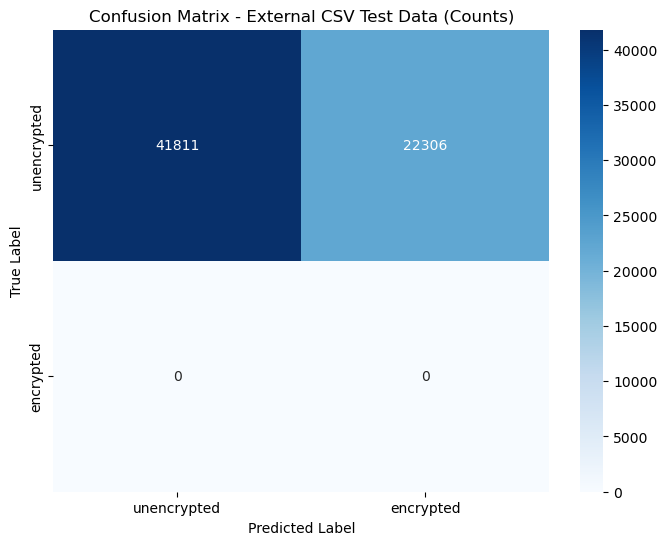


--- Evaluating Best Model on New External CSV Data (Normalized Percentages) ---

--- Evaluation Summary for External CSV Test Data ---
Overall Accuracy:         65.21%
Macro Average Precision:  50.00%
Macro Average Recall:     32.61%
Macro Average F1-score:   39.47%
Weighted Avg Precision:   100.00%
Weighted Avg Recall:      65.21%
Weighted Avg F1-score:    78.94%

Full Classification Report:
              precision    recall  f1-score   support

 unencrypted     1.0000    0.6521    0.7894     64117
   encrypted     0.0000    0.0000    0.0000         0

    accuracy                         0.6521     64117
   macro avg     0.5000    0.3261    0.3947     64117
weighted avg     1.0000    0.6521    0.7894     64117


Confusion Matrix (Normalized (Percentages by True Class) - Rows: True, Cols: Predicted):
Confusion matrix figure saved to: evaluation_figures_270feat_v7\confusion_matrix_external_csv_test_data_normalized_percent.png


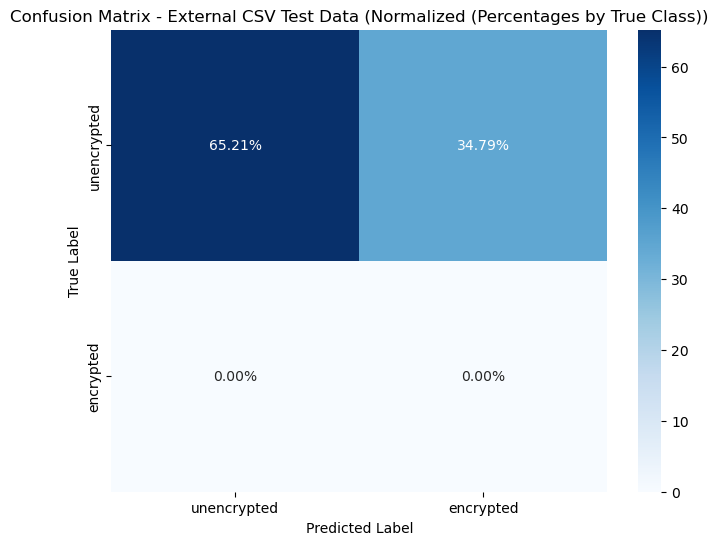

In [4]:
if __name__ == '__main__':
    # --- 5. Evaluate on a new external CSV test dataset (all class 0) ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEQUENCE_LENGTH = 4096
    INPUT_FEATURES_DIM = 270 # Based on extract_all_features output
    NUM_CLASSES = 2
    BATCH_SIZE = 32
    CLASS_NAMES_FOR_PLOT = ['unencrypted', 'encrypted'] # Class 0, Class 1
    model_checkpoint_dir = "model_checkpoints_270feat_v7"
    eval_fig_dir = "evaluation_figures_270feat_v7"
    best_model_path_final = os.path.join(model_checkpoint_dir, "model_epoch_100.pth")   
    
    print("\n\n--- Evaluating on a New External CSV Test Dataset (All Class 0 Samples) ---")
    # IMPORTANT: USER MUST CHANGE THIS PATH
    external_csv_filepath = "D:\\DATASETS\\dataset_itctext + mnp\\fragments\\64117\\all_unenc(50_50).csv"
    # Example: external_csv_filepath = "/path/to/my_unencrypted_data.csv"

    if not os.path.exists(best_model_path_final):
        print(f"Error: Best model checkpoint not found at {best_model_path_final}. Cannot evaluate external dataset.")
    elif not os.path.exists(external_csv_filepath):
        print(f"External CSV file specified does not exist: {external_csv_filepath}. Create this file or change the path.")
    else:
        print(f"Loading new test data from: {external_csv_filepath}")
        # try:
        # Load raw byte sequences from CSV
        # Assuming each row is a sequence of comma-separated integers (bytes)
        # If your CSV is different (e.g., space-separated), change delimiter
        new_raw_data_np = np.loadtxt(external_csv_filepath, delimiter=',', dtype=np.uint8)
        #new_raw_data_np = new_raw_data_np[:10000, :]
        # Handle cases: empty file or single row that isn't a single sample
        if new_raw_data_np.size == 0:
            raise ValueError("External CSV file is empty.")
        if new_raw_data_np.ndim == 1: # If loadtxt returns a 1D array (single row CSV)
            if new_raw_data_np.shape[0] == SEQUENCE_LENGTH:
                new_raw_data_np = new_raw_data_np.reshape(1, -1) # Reshape to (1, SEQUENCE_LENGTH)
            else:
                raise ValueError(f"Single row in CSV does not have expected sequence length {SEQUENCE_LENGTH}. Found {new_raw_data_np.shape[0]}")
        elif new_raw_data_np.shape[1] != SEQUENCE_LENGTH: # For multi-row CSVs
            raise ValueError(f"Data in CSV rows do not have expected sequence length {SEQUENCE_LENGTH}. Found {new_raw_data_np.shape[1]}")

        print(f"Loaded {new_raw_data_np.shape[0]} samples from external CSV.")

        new_labels_np = np.zeros(new_raw_data_np.shape[0], dtype=np.int64)  # All class 0

        print("Extracting features for the new external test data...")
        new_extracted_features_list = []
        for i in range(new_raw_data_np.shape[0]):
            if (i + 1) % 100 == 0 or (i+1) == new_raw_data_np.shape[0]:
                print(f"  Extracting features for external sample {i+1}/{new_raw_data_np.shape[0]}")
            new_extracted_features_list.append(extract_all_features(new_raw_data_np[i]))
        new_X_features_np = np.array(new_extracted_features_list, dtype=np.float32)
        print(f"Feature extraction for external data complete. Shape: {new_X_features_np.shape}")

        print(f"Loading scaler state from best model checkpoint: {best_model_path_final}")
        checkpoint = torch.load(best_model_path_final, map_location=device, weights_only=False)
        loaded_scaler = StandardScaler()
        if 'scaler_mean' in checkpoint and 'scaler_scale' in checkpoint:
            loaded_scaler.mean_ = checkpoint['scaler_mean']
            loaded_scaler.scale_ = checkpoint['scaler_scale']
            new_X_features_scaled = loaded_scaler.transform(new_X_features_np)
            print("Applied loaded scaler to external data features.")
        else:
            print("Warning: Scaler state (mean/scale) not found in checkpoint. Using unscaled features. THIS IS LIKELY TO GIVE POOR RESULTS.")
            new_X_features_scaled = new_X_features_np # Fallback, not recommended

        new_X_tensor = torch.tensor(new_X_features_scaled, dtype=torch.float32)
        new_y_tensor = torch.tensor(new_labels_np, dtype=torch.long)
        new_test_dataset = TensorDataset(new_X_tensor, new_y_tensor)
        new_test_loader = DataLoader(new_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # Ensure the best model is loaded and on the correct device for this evaluation
        model_for_external_eval = DNN_BFLCp(input_features=INPUT_FEATURES_DIM, num_classes=NUM_CLASSES)
        model_for_external_eval.load_state_dict(checkpoint['model_state_dict'])
        model_for_external_eval.to(device)
        model_for_external_eval.eval() # Explicitly set to eval mode

        print("\n--- Evaluating Best Model on New External CSV Data (Raw Counts) ---")
        evaluate_model_and_plot_confusion_matrix(model_for_external_eval, new_test_loader, device, CLASS_NAMES_FOR_PLOT,
                                                    dataset_name="External CSV Test Data",
                                                    save_fig_dir=eval_fig_dir, normalize_cm=False)
        print("\n--- Evaluating Best Model on New External CSV Data (Normalized Percentages) ---")
        evaluate_model_and_plot_confusion_matrix(model_for_external_eval, new_test_loader, device, CLASS_NAMES_FOR_PLOT,
                                                    dataset_name="External CSV Test Data",
                                                    save_fig_dir=eval_fig_dir, normalize_cm=True)
        # except FileNotFoundError:
        #     print(f"Error: External CSV file not found at {external_csv_filepath}. Please check the path.")
        # except ValueError as ve:
        #     print(f"Error processing CSV file '{external_csv_filepath}': {ve}")
        #     print("Please ensure the CSV contains only numbers, has no header, and each row has 4096 comma-separated byte values (0-255).")
        # except Exception as e:
        #     print(f"An unexpected error occurred while processing the external CSV: {e}")    
        